# KdV walkthrough: from a field to its equation

KD recovers the Korteweg-de Vries equation, `u_t = -u u_x - 0.0025 u_xxx`, from
a bundled benchmark field whose equation is known. The search is SGA-PDE at the
budget its recovery suite validates (200 generations, population 20, seed 42).
Four calls carry the whole walkthrough: load the data, draw it, fit, render the
report. Every output below is committed from one execution, so the numbers are
what the code printed.

In [1]:
import kd

## The data

The KdV field ships with KD as a 256 by 201 grid in `x` and `t`, taken from the
SGA-PDE benchmark set. `kd.preview` audits the grid spacing, the field values
and the left-hand side before any search runs; `plot_field` draws the field as
it was measured.

In [2]:
dataset = kd.load_kdv()
kd.preview(dataset)

Dataset: kdv
Axes:
     x | n=256  | range [-1.000, 0.992] | step 0.007812 (uniform)
     t | n=201  | range [0.000, 1.000] | step 0.005 (uniform)
Fields:
     u | dtype=float64 | shape=(256, 201) | min=-1.000 max=2.309 mean=0.000 (NaN=0)
LHS: u_t  (field='u', axis='t')
Status: ready to fit


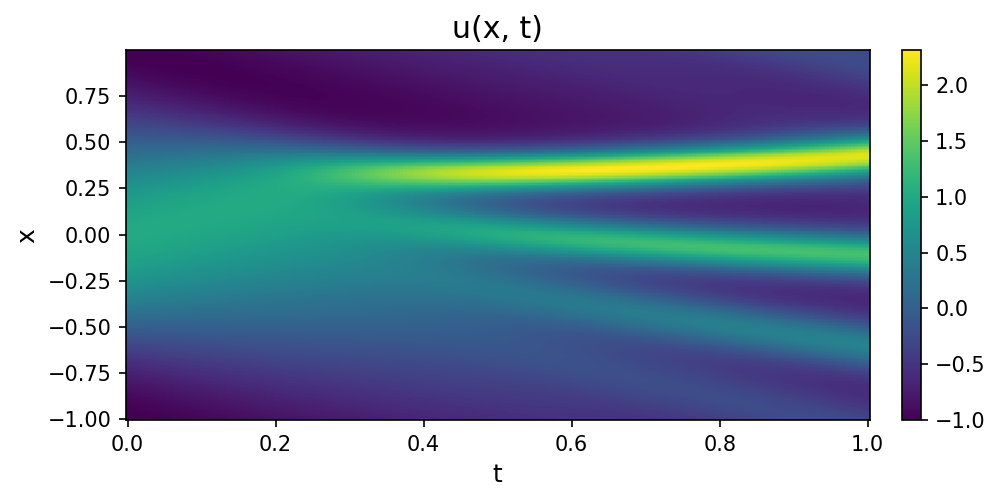

In [3]:
kd.viz.plots.plot_field(dataset)

## Fit SGA-PDE

`generations=200` and `seed=42` are the settings the KdV recovery suite pins;
population, tree depth and the sparse-regression sweep stay at the `SGAConfig`
defaults. The third-derivative coefficient is 400 times smaller than the
advection coefficient, which is what the coarse sweep has to keep. The fit took
about 13 minutes in this run.

In [4]:
model = kd.Model(algorithm="sga", generations=200, seed=42, verbose=False).fit(dataset)
model

Model(algorithm='sga', fitted=True, best_expr='u_t = -0.0025*u_x_xx - 0.5*(u**2)_x', best_score=-19.42)

## Recovered law and the reference

SGA-PDE writes the advection term as `-0.5 * diff_x(mul(u, u))`, which is
`-u u_x` by the product rule, and `u_xxx` as the nested `diff2_x(diff_x(u))`.
In this run the fitted coefficients are `-0.499999` for the advection term
(reference `-0.5`, relative error 3.0e-6) and `-0.002500` for the dispersion
term (reference `-0.0025`, relative error 3.7e-5); the search selected no other
term.

In [5]:
print(f"Discovered : {model.result_.equation}")
print(f"Reference  : {dataset.ground_truth}")

Discovered : u_t = -0.0025*u_x_xx - 0.5*(u**2)_x
Reference  : u_t = -u * u_x - 0.0025 * u_xxx


## The report

`model.report` renders every figure this fit supports and one HTML page that
embeds them: the convergence curve, the parity plot, the equation and its tree,
the coefficient bars, the residual histogram and heatmap, the measured field
next to the field integrated from the discovered equation, the time slices, the
error heatmap, the PDE residual field, and SGA-PDE's own search diagnostics.
The page is shown below; the same files are written to the output directory.

In [6]:
model.report("../out/kdv_walkthrough")

ReportResult(figures=[PosixPath('../out/kdv_walkthrough/convergence.svg'), PosixPath('../out/kdv_walkthrough/parity.svg'), PosixPath('../out/kdv_walkthrough/equation.svg'), PosixPath('../out/kdv_walkthrough/equation_tree.svg'), PosixPath('../out/kdv_walkthrough/residual.svg'), PosixPath('../out/kdv_walkthrough/coefficient_bar.svg'), PosixPath('../out/kdv_walkthrough/field_comparison.svg'), PosixPath('../out/kdv_walkthrough/pde_residual_field.svg'), PosixPath('../out/kdv_walkthrough/time_slices.svg'), PosixPath('../out/kdv_walkthrough/error_heatmap.svg'), PosixPath('../out/kdv_walkthrough/plugin_population_diversity.svg'), PosixPath('../out/kdv_walkthrough/plugin_complexity_evolution.svg'), PosixPath('../out/kdv_walkthrough/plugin_fitness_spread.svg'), PosixPath('../out/kdv_walkthrough/plugin_surrogate_training.svg'), PosixPath('../out/kdv_walkthrough/plugin_genome_tree.svg')], data_files=[], report=PosixPath('../out/kdv_walkthrough/report.html'), warnings=["plugin plot 'surrogate_training': No data (no surrogate training logged for this run)"])

## Next steps

- [`09_compare_algorithms.py`](../09_compare_algorithms.py): every algorithm
  on one dataset, scored with one ruler; [`08_dlga.py`](../08_dlga.py) runs
  DLGA, which takes every derivative from a trained neural-network surrogate.
- [`04_noisy_data.py`](../04_noisy_data.py): `derivatives="autograd"` routes
  SGA-PDE's `u_x` and `u_t` terminals through such a surrogate on a noisy
  field (`kd.data.xu2020_relative` is the noise recipe); derivative operators
  inside a candidate tree stay finite-difference.
- [`21_sketch_discovery.py`](../21_sketch_discovery.py): pin the advection
  term with its coefficient and search only for the remainder.